<h3 style="font-family:'Times New Roman'; color:red;"><b>1. Imports & Configuration</b></h3>
<hr>

In [2]:
import os, time, warnings
warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn            as sns
import json
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay,
)

from xgboost              import XGBClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone   # FIX: used to mirror real fitted models in the learning curve (Section 11a)

import shap
import joblib

seed    = 42
n_folds = 5          # Stratified K-Fold
cv_jobs = -1         # use all CPU cores for CV

ACCENT = '#c84b1e'
BLUE   = '#1a5fa8'
GREEN  = '#1a6b3f'
AMBER  = '#d68910'
PURPLE = '#8e44ad'
GREY   = '#636e72'

sns.set_style('whitegrid')
sns.set_context('notebook')
plt.rcParams.update({
    'figure.facecolor': '#fafaf8',
    'axes.facecolor'  : '#fafaf8',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'font.family'     : 'DejaVu Sans',
})

<h3 style="font-family:'Times New Roman'; color:red;"><b>2. Load Artifacts & Scored Dataset</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Load all artifacts from notebook 03 and the scored dataset from notebook 04, and confirm the shapes and anomaly rates look right before training anything.
</b></i></p>
<hr>

In [3]:
# Pre-split arrays
X_train_robust = np.load(f'models/artifacts/X_train_robust.npy')
X_test_robust  = np.load(f'models/artifacts/X_test_robust.npy')

X_train_df = pd.read_csv(f'models/artifacts/X_train.csv', index_col=0)
X_test_df  = pd.read_csv(f'models/artifacts/X_test.csv',  index_col=0)
y_train    = pd.read_csv(f'models/artifacts/y_train.csv').squeeze()
y_test     = pd.read_csv(f'models/artifacts/y_test.csv').squeeze()

feature_cols = joblib.load(f'models/artifacts/model_feature_cols.pkl')

print(f'Train: {X_train_robust.shape} | Test: {X_test_robust.shape}')
print(f'y_train anomaly rate: {y_train.mean():.2%} | y_test: {y_test.mean():.2%}')
print(f'Features loaded from model_feature_cols.pkl: {len(feature_cols)}')

Train: (37333, 43) | Test: (9334, 43)
y_train anomaly rate: 9.56% | y_test: 9.57%
Features loaded from model_feature_cols.pkl: 43


In [4]:
# Full-dataset scored listings
scored_df = pd.read_csv('data/preprocessed/model_scored_listings.csv')

print(f'model_scored_listings.csv shape : {scored_df.shape}')
print()
print('Ensemble vote distribution (full dataset):')
print(scored_df['ensemble_votes'].value_counts().sort_index().to_string())
print()
print(f'High-confidence anomalies (2+ votes): {scored_df["high_conf_anomaly"].sum():,} ',
      f'({scored_df["high_conf_anomaly"].mean()*100:.1f}%)')

model_scored_listings.csv shape : (46667, 84)

Ensemble vote distribution (full dataset):
ensemble_votes
0    37406
1     6101
2     2255
3      905

High-confidence anomalies (2+ votes): 3,160  (6.8%)


<h3 style="font-family:'Times New Roman'; color:red;"><b>3. Pseudo-Label Construction</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Build train and test pseudo-labels from notebook 04's ensemble output, aligned strictly by index. Training uses only the confidence-filtered rows; the test set stays full and unfiltered for honest evaluation.
</b></i></p>
<hr>


In [5]:
scored_df = scored_df.reset_index(drop=True)

In [ ]:
# listing is selected by its original row identifier


if LABEL_VERSION == 'v2':
    label_file           = 'models/artifacts/y_ensemble_v2.csv'
    confident_label_file = 'models/artifacts/y_ensemble_confident_v2.csv'
else:
    label_file           = 'models/artifacts/y_ensemble.csv'
    confident_label_file = 'models/artifacts/y_ensemble_confident.csv'

y_ensemble = pd.read_csv(label_file, index_col=0).squeeze()
print(f'Label version: {LABEL_VERSION}  (loaded from {label_file})')

y_pseudo_train_full = y_ensemble.loc[X_train_df.index].values
y_pseudo_test        = y_ensemble.loc[X_test_df.index].values

USE_CONFIDENCE_FILTER = True   # set False to reproduce the original unfiltered behaviour

if USE_CONFIDENCE_FILTER:
    try:
        y_ensemble_confident = pd.read_csv(
            confident_label_file, index_col=0
        ).squeeze()
        train_eligible_mask = X_train_df.index.isin(y_ensemble_confident.index)

        n_before = len(X_train_df)

        X_train_robust = X_train_robust[train_eligible_mask]
        X_train_df     = X_train_df.loc[train_eligible_mask]
        y_train         = y_train[train_eligible_mask].reset_index(drop=True)
        y_pseudo_train  = y_pseudo_train_full[train_eligible_mask]

        n_after = len(X_train_df)
        print(f'Confidence filter applied: {n_before:,} -> {n_after:,} training rows '
              f'({n_before - n_after:,} ambiguous 1-vote rows excluded from training)')
    except FileNotFoundError:
        print(f'{confident_label_file} not found -- run the updated NB04 Section 13/14 first. '
              f'Falling back to the unfiltered pseudo-label.')
        y_pseudo_train = y_pseudo_train_full
else:
    y_pseudo_train = y_pseudo_train_full

pseudo_y = np.concatenate([y_pseudo_train, y_pseudo_test])

assert len(y_pseudo_train) == X_train_robust.shape[0], "Train size mismatch"
assert len(y_pseudo_test)  == X_test_robust.shape[0],  "Test size mismatch"
print(f"Label alignment: using NB04 {'refined (v2)' if LABEL_VERSION=='v2' else 'vote-based (v1)'} "
      f"ensemble pseudo-labels")


Label version: v2  (loaded from models/artifacts/y_ensemble_v2.csv)
Confidence filter applied: 37,333 -> 37,090 training rows (243 ambiguous 1-vote rows excluded from training)
Label alignment: using NB04 refined (v2) ensemble pseudo-labels


In [7]:
print('Pseudo-label construction:')
print(f'  Total pseudo-anomalies (train+test) : {pseudo_y.sum():,} ({pseudo_y.mean()*100:.1f}%)')
print(f'  Pseudo-anomaly rate in train split  : {y_pseudo_train.mean()*100:.1f}%')
print(f'  Pseudo-anomaly rate in test split   : {y_pseudo_test.mean()*100:.1f}%')
print()
print('Class balance in training set:')
unique, counts = np.unique(y_pseudo_train, return_counts=True)
for u, c in zip(unique, counts):
    label = "Anomaly" if u == 1 else "Normal"
    print(f'  {label} ({int(u)}): {c:,} ({c/len(y_pseudo_train)*100:.1f}%)')
pos_weight_val = (y_pseudo_train == 0).sum() / max((y_pseudo_train == 1).sum(), 1)
print(f'\nscale_pos_weight for XGBoost: {pos_weight_val:.2f}')

Pseudo-label construction:
  Total pseudo-anomalies (train+test) : 3,160 (6.8%)
  Pseudo-anomaly rate in train split  : 6.6%
  Pseudo-anomaly rate in test split   : 7.6%

Class balance in training set:
  Normal (0): 34,644 (93.4%)
  Anomaly (1): 2,446 (6.6%)

scale_pos_weight for XGBoost: 14.16


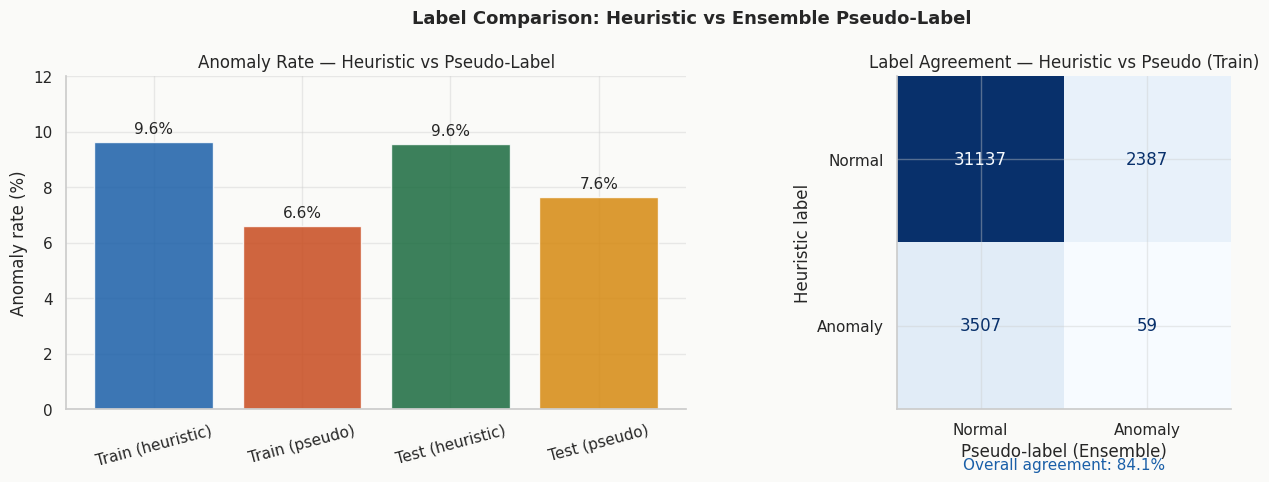

In [8]:
# Visual check — compare pseudo-label rate vs heuristic label rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label Comparison: Heuristic vs Ensemble Pseudo-Label',
             fontsize=13, fontweight='bold')

# Left: side-by-side bar for heuristic vs pseudo-label anomaly rates
labels_comp = ['Train (heuristic)', 'Train (pseudo)', 'Test (heuristic)', 'Test (pseudo)']
rates_comp  = [
    y_train.mean()*100, y_pseudo_train.mean()*100,
    y_test.mean()*100,  y_pseudo_test.mean()*100,
]
colors_comp = [BLUE, ACCENT, GREEN, AMBER]
bars = axes[0].bar(labels_comp, rates_comp, color=colors_comp, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
axes[0].set_ylabel('Anomaly rate (%)')
axes[0].set_title('Anomaly Rate — Heuristic vs Pseudo-Label')
axes[0].set_ylim(0, max(rates_comp) * 1.25)
axes[0].tick_params(axis='x', rotation=15)

# Right: confusion matrix — how well does pseudo-label agree with heuristic?
cm_agreement = confusion_matrix(y_train.values, y_pseudo_train)
disp = ConfusionMatrixDisplay(cm_agreement, display_labels=['Normal', 'Anomaly'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Label Agreement — Heuristic vs Pseudo (Train)')
axes[1].set_xlabel('Pseudo-label (Ensemble)')
axes[1].set_ylabel('Heuristic label')

agree_pct = (cm_agreement[0,0] + cm_agreement[1,1]) / cm_agreement.sum() * 100
axes[1].text(0.5, -0.18, f'Overall agreement: {agree_pct:.1f}%',
             transform=axes[1].transAxes, ha='center', fontsize=11, color=BLUE)

plt.tight_layout()
plt.savefig(f'reports/figures/_label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>The pseudo-label is rarer than the heuristic label:</b> the ensemble pseudo-anomaly rate only counts listings with 2 or more unsupervised model votes, which is a stricter bar than the original heuristic proxy.</li>
<li><b>Training set is now confidence-filtered:</b> with <code>USE_CONFIDENCE_FILTER=True</code>, the ambiguous 1-vote rows are dropped from training (see the exact before/after row counts printed above). <code>scale_pos_weight</code> is computed automatically from the filtered set in Section 4a, so it will reflect the new, smaller training population.</li>
<li><i>Note: run this notebook end-to-end to regenerate the exact percentages and counts for this section — they will differ slightly from earlier runs now that the ambiguous rows are excluded from training.</i></li>
</i></ul>
<hr>


<h3 style="font-family:'Times New Roman'; color:red;"><b>4. Cross-Validation Setup</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Set up 5-fold stratified cross-validation to get an honest performance estimate before the final test-set check. Stratification matters here because the pseudo-label is imbalanced (~6-10% anomaly rate), so every fold needs the same anomaly proportion.
</b></i></p>
<hr>

In [9]:
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

def report_cv(name, cv_results):
    """Print mean ± std for each CV metric and return a summary dict."""
    print(f'\n── {name} — {n_folds}-Fold Stratified CV ──')
    print(f'  {"Metric":<22} {"Mean":>8}  {"Std":>8}')
    summary = {}
    for metric in cv_scoring:
        key    = f'test_{metric}'
        mean_v = cv_results[key].mean()
        std_v  = cv_results[key].std()
        print(f'  {metric:<22} {mean_v:>8.4f}  ±{std_v:.4f}')
        summary[metric] = {'mean': mean_v, 'std': std_v}
    return summary

print(f'StratifiedKFold ready — {n_folds} folds, random_state={seed}')
print(f'Class distribution in training set:')
for v, n in zip(*np.unique(y_pseudo_train, return_counts=True)):
    print(f'  class {int(v)}: {n:,}')

StratifiedKFold ready — 5 folds, random_state=42
Class distribution in training set:
  class 0: 34,644
  class 1: 2,446


In [10]:
assert X_train_robust.shape[0] == len(y_pseudo_train), (
    f"Row count mismatch: X_train_robust has {X_train_robust.shape[0]} rows "
    f"but y_pseudo_train has {len(y_pseudo_train)} labels.")

assert X_test_robust.shape[0] == len(y_pseudo_test), (
    f"Row count mismatch: X_test_robust has {X_test_robust.shape[0]} rows "
    f"but y_pseudo_test has {len(y_pseudo_test)} labels.")

assert X_train_robust.shape[1] == len(feature_cols), (
    f"Feature count mismatch: X_train_robust has {X_train_robust.shape[1]} cols "
    f"but model_feature_cols has {len(feature_cols)} entries. Re-run NB03.")

print("Shape assertions: X_train_robust / y_pseudo_train / feature_cols all consistent")
print(f"  Train rows: {X_train_robust.shape[0]:,}  |  Test rows: {X_test_robust.shape[0]:,}")
print(f"  Features  : {X_train_robust.shape[1]}")
print(f"  Train anomaly rate: {y_pseudo_train.mean():.2%}  |  Test: {y_pseudo_test.mean():.2%}")


Shape assertions: X_train_robust / y_pseudo_train / feature_cols all consistent
  Train rows: 37,090  |  Test rows: 9,334
  Features  : 43
  Train anomaly rate: 6.59%  |  Test: 7.65%


<h3 style="font-family:'Times New Roman'; color:red;"><b>4a. Baseline Model Comparison</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Run a quick 5-fold CV comparison across five simple models (Dummy, Logistic Regression, Decision Tree, Random Forest, XGBoost) to confirm there's real signal in the data before building the three main models in detail.
</b></i></p>
<hr>

In [11]:
# scale_pos_weight: auto-computed from the training pseudo-label
neg_count = int((y_pseudo_train == 0).sum())
pos_count = int((y_pseudo_train == 1).sum())
spw       = neg_count / max(pos_count, 1)

print(f'Class counts  — Normal: {neg_count:,}  |  Anomaly: {pos_count:,}')
print(f'scale_pos_weight = {neg_count} / {pos_count} = {spw:.2f}')

Class counts  — Normal: 34,644  |  Anomaly: 2,446
scale_pos_weight = 34644 / 2446 = 14.16


In [12]:
baseline_models = {
    'Dummy (majority class)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression':    LogisticRegression(
                                  class_weight='balanced',
                                  max_iter=2000,
                                  C=1.0,
                                  solver='lbfgs',
                                  random_state=seed,
                              ),
    'Decision Tree (d=5)':    DecisionTreeClassifier(
                                  max_depth=5,
                                  class_weight='balanced',
                                  random_state=seed,
                              ),
    'Random Forest':          RandomForestClassifier(
                                  n_estimators=200,
                                  max_depth=10,
                                  class_weight='balanced',
                                  random_state=seed,
                                  n_jobs=-1,
                              ),
    'XGBoost (default)':      XGBClassifier(
                                  n_estimators=300,
                                  max_depth=4,
                                  scale_pos_weight=spw,
                                  eval_metric='aucpr',
                                  random_state=seed,
                                  n_jobs=-1,
                                  verbosity=0,
                              ),
}


In [13]:
print(f'Running 5-fold CV for {len(baseline_models)} baseline models...\n')
baseline_results = {}

for name, model in baseline_models.items():
    t0 = time.time()
    cv_res = cross_validate(
        model, X_train_robust, y_pseudo_train,
        cv=skf,
        scoring=['roc_auc', 'average_precision', 'f1'],
        n_jobs=-1,
    )
    elapsed = time.time() - t0
    baseline_results[name] = {
        'ROC-AUC': cv_res['test_roc_auc'].mean(),
        'PR-AUC':  cv_res['test_average_precision'].mean(),
        'F1':      cv_res['test_f1'].mean(),
        'ROC std': cv_res['test_roc_auc'].std(),
    }
    print(f'{name:<28}: AUC={baseline_results[name]["ROC-AUC"]:.4f}±{baseline_results[name]["ROC std"]:.4f}'
          f'  PR-AUC={baseline_results[name]["PR-AUC"]:.4f}'
          f'  F1={baseline_results[name]["F1"]:.4f}'
          f'  ({elapsed:.1f}s)')

Running 5-fold CV for 5 baseline models...

Dummy (majority class)      : AUC=0.5000±0.0000  PR-AUC=0.0659  F1=0.0000  (2.3s)
Logistic Regression         : AUC=0.7354±0.0976  PR-AUC=0.3976  F1=0.1792  (0.6s)
Decision Tree (d=5)         : AUC=0.9059±0.0126  PR-AUC=0.5999  F1=0.4229  (1.8s)
Random Forest               : AUC=0.9881±0.0017  PR-AUC=0.8874  F1=0.7946  (42.7s)
XGBoost (default)           : AUC=0.9982±0.0003  PR-AUC=0.9814  F1=0.9264  (8.4s)


In [ ]:

SANITY_AUC_BAR = 0.60
non_dummy = {k: v for k, v in baseline_results.items() if 'Dummy' not in k}
best_baseline_name = max(non_dummy, key=lambda k: non_dummy[k]['ROC-AUC'])
best_baseline_auc  = non_dummy[best_baseline_name]['ROC-AUC']

print(f'Label version: {LABEL_VERSION}')
print(f'Best non-dummy baseline: {best_baseline_name} (ROC-AUC={best_baseline_auc:.4f})')

if best_baseline_auc < SANITY_AUC_BAR:
    print(f'\n✗ WARNING: best baseline ROC-AUC ({best_baseline_auc:.4f}) is still below the '
          f'{SANITY_AUC_BAR:.2f} sanity bar. The pseudo-label may still carry little learnable '
          f'signal. Revisit NB04 Section 14 (IF_WEIGHT/OCSVM_WEIGHT/TARGET_POSITIVE_RATE) before '
          f'trusting the model comparison, learning curves, or NB06 tuning below.')
else:
    print(f'\n✓ Best baseline clears the {SANITY_AUC_BAR:.2f} ROC-AUC sanity bar -- '
          f'model comparison and learning curves below are measuring real signal, not noise.')


Label version: v2
Best non-dummy baseline: XGBoost (default) (ROC-AUC=0.9982)

✓ Best baseline clears the 0.60 ROC-AUC sanity bar -- model comparison and learning curves below are measuring real signal, not noise.


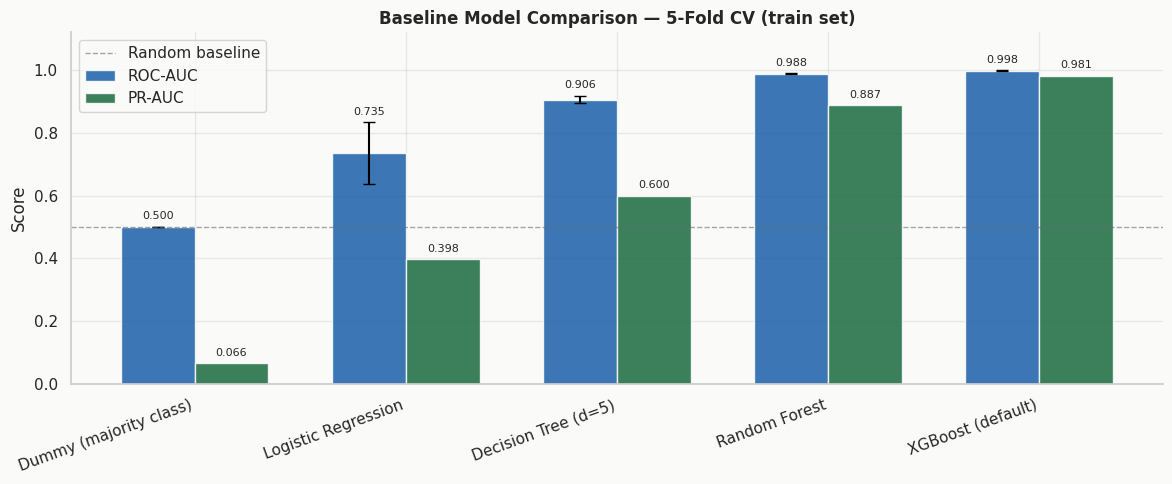

In [15]:
# Baseline comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))

names   = list(baseline_results.keys())
aucs    = [baseline_results[n]['ROC-AUC'] for n in names]
pr_aucs = [baseline_results[n]['PR-AUC']  for n in names]
stds    = [baseline_results[n]['ROC std']  for n in names]

x = np.arange(len(names))
w = 0.35

bars1 = ax.bar(x - w/2, aucs,    w, label='ROC-AUC', color=BLUE,  alpha=0.85, yerr=stds, capsize=4)
bars2 = ax.bar(x + w/2, pr_aucs, w, label='PR-AUC',  color=GREEN, alpha=0.85)

ax.bar_label(bars1, fmt='%.3f', padding=4, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=4, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison — 5-Fold CV (train set)', fontweight='bold')
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color=GREY, linestyle='--', linewidth=1, alpha=0.6, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Every baseline clears the random-guess bar:</b> ROC-AUC ranges from 0.7354 (Logistic Regression) up to 0.9982 (default XGBoost), all well above the Dummy baseline's 0.5000.</li>
<li><b>Default XGBoost is already the strongest baseline:</b> it has the best F1 (0.9264) and the best ROC-AUC (0.9982), while the majority-class Dummy classifier gets F1 = 0.0000 by definition.</li>
<li><b>Random Forest is the slowest baseline by a wide margin:</b> 42.7 seconds to cross-validate, far more than any other baseline, even though XGBoost gets better results in under 10 seconds.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>5. Model 1 — XGBoost Classifier</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Train an XGBoost classifier that handles class imbalance with scale_pos_weight, and evaluate it using PR-AUC (aucpr) instead of accuracy, since accuracy is misleading when anomalies are rare.
</b></i></p>
<hr>

In [16]:
print('Starting XGBoost cross-validation...')
t0 = time.time()

xgb_clf = XGBClassifier(
    n_estimators=80,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    gamma=2,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=10.0,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=seed,
    n_jobs=-1,
    verbosity=0,
)
xgb_cv = cross_validate(
    xgb_clf, X_train_robust, y_pseudo_train,
    cv=skf, scoring=cv_scoring, n_jobs=-1, return_train_score=True
)

xgb_cv_time = time.time() - t0
xgb_cv_summary = report_cv('XGBoost', xgb_cv)

# Overfitting check:
xgb_train_f1 = xgb_cv['train_f1'].mean()
xgb_cv_f1    = xgb_cv['test_f1'].mean()
gap = xgb_train_f1 - xgb_cv_f1
print(f'  Train F1 (mean): {xgb_train_f1:.4f}  |  CV F1 (mean): {xgb_cv_f1:.4f}  |  Gap: {gap:.4f}')
if gap > 0.15:
    print(' WARNING: Large train/CV gap — model may be overfitting. Consider reducing n_estimators or max_depth.')
else:
    print('Train/CV gap is acceptable (<0.15)')
print(f'\n  CV completed in {xgb_cv_time:.1f}s')

Starting XGBoost cross-validation...

── XGBoost — 5-Fold Stratified CV ──
  Metric                     Mean       Std
  accuracy                 0.9224  ±0.0025
  precision                0.4555  ±0.0090
  recall                   0.8986  ±0.0167
  f1                       0.6045  ±0.0102
  roc_auc                  0.9735  ±0.0041
  average_precision        0.7901  ±0.0263
  Train F1 (mean): 0.6141  |  CV F1 (mean): 0.6045  |  Gap: 0.0096
Train/CV gap is acceptable (<0.15)

  CV completed in 2.6s


In [ ]:
# Retrain XGBoost on the FULL training set (no held-out folds)
print('Retraining XGBoost on full train set...')
t0 = time.time()
xgb_clf.fit(X_train_robust, y_pseudo_train)
xgb_train_time = time.time() - t0
print(f'XGBoost retrained in {xgb_train_time:.2f}s')

# Test-set evaluation
t0       = time.time()
xgb_pred = xgb_clf.predict(X_test_robust)
xgb_prob = xgb_clf.predict_proba(X_test_robust)[:, 1]
xgb_infer_time = time.time() - t0

# Evaluate against BOTH pseudo-label and heuristic label
for label_name, y_eval in [('pseudo-label', y_pseudo_test), ('heuristic', y_test.values)]:
    acc  = accuracy_score(y_eval, xgb_pred)
    prec = precision_score(y_eval, xgb_pred, zero_division=0)
    rec  = recall_score(y_eval, xgb_pred, zero_division=0)
    f1   = f1_score(y_eval, xgb_pred, zero_division=0)
    roc  = roc_auc_score(y_eval, xgb_prob)
    pr   = average_precision_score(y_eval, xgb_prob)
    print(f'\nXGBoost — Test set vs {label_name}:')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}')
joblib.dump(xgb_clf, f'models/xgboost_v1.pkl')

Retraining XGBoost on full train set...
XGBoost retrained in 0.70s

XGBoost — Test set vs pseudo-label:
  Accuracy=0.9159  Precision=0.4741  Recall=0.9118  F1=0.6239
  ROC-AUC=0.9725  PR-AUC=0.7981

XGBoost — Test set vs heuristic:
  Accuracy=0.7632  Precision=0.0204  Recall=0.0314  F1=0.0247
  ROC-AUC=0.3219  PR-AUC=0.0687


['models/xgboost_v1.pkl']

In [18]:
# Register XGBoost results for NB06 auto-selection

registry_path = 'models/artifacts/supervised_results_registry.json'

# Start fresh — XGBoost is always registered first in NB05
supervised_results_registry = []

supervised_results_registry.append({
    'name'                     : 'XGBoost',
    'artifact_path'            : 'models/xgboost_v1.pkl',
    'model_type'               : 'supervised',
    'cv_pr_auc_mean'           : float(xgb_cv['test_average_precision'].mean()),
    'cv_pr_auc_std'            : float(xgb_cv['test_average_precision'].std()),
    'cv_roc_auc_mean'          : float(xgb_cv['test_roc_auc'].mean()),
    'test_pr_auc_vs_pseudo'    : float(average_precision_score(y_pseudo_test, xgb_prob)),
    'test_roc_auc_vs_pseudo'   : float(roc_auc_score(y_pseudo_test, xgb_prob)),
    'test_pr_auc_vs_heuristic' : float(average_precision_score(y_test.values, xgb_prob)),
    'test_roc_auc_vs_heuristic': float(roc_auc_score(y_test.values, xgb_prob)),
})

with open(registry_path, 'w') as f:
    json.dump(supervised_results_registry, f, indent=2)

print(f'Registry created — XGBoost registered.')
print(f'  CV PR-AUC  : {xgb_cv["test_average_precision"].mean():.4f} '
      f'± {xgb_cv["test_average_precision"].std():.4f}')
print(f'  PR-AUC vs pseudo   : {average_precision_score(y_pseudo_test, xgb_prob):.4f}')
print(f'  PR-AUC vs heuristic: {average_precision_score(y_test.values, xgb_prob):.4f}')

Registry created — XGBoost registered.
  CV PR-AUC  : 0.7901 ± 0.0263
  PR-AUC vs pseudo   : 0.7981
  PR-AUC vs heuristic: 0.0687


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>CV performance is strong:</b> 5-fold CV against the pseudo-label gives ROC-AUC 0.9735 ± 0.0041 and PR-AUC 0.7901 ± 0.0263, far above the 6.6% base rate.</li>
<li><b>Heuristic-label results are much weaker than pseudo-label results:</b> on the test set, XGBoost reaches ROC-AUC 0.3219 and PR-AUC 0.0687 against the heuristic label, versus ROC-AUC 0.9725 and PR-AUC 0.7981 against the pseudo-label it was trained on. The model is learning the unsupervised ensemble pattern it was trained on, not the original heuristic rule.</li>
<li><b>Train/CV gap is small:</b> train F1 is 0.6141 vs CV F1 0.6045, a gap of 0.0096, well under the notebook's 0.15 cutoff for overfitting.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>6. Model 2 — Random Forest Classifier</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Train a Random Forest classifier using class_weight='balanced' to handle class imbalance, and compare it against XGBoost since the two tend to make different kinds of errors.
</b></i></p>
<hr>

In [19]:
print('Starting Random Forest cross-validation...')
t0 = time.time()

rf_clf=RandomForestClassifier(
    n_estimators=700,
    max_depth=20,          # or None
    min_samples_leaf=10,   # instead of 55
    min_samples_split=20,  # instead of 65
    max_samples=0.8,
    max_features="sqrt",
    class_weight="balanced",
    ccp_alpha=0.001,
    random_state=seed,
    n_jobs=-1,
)

rf_cv = cross_validate(
    rf_clf, X_train_robust, y_pseudo_train,
    cv=skf, scoring=cv_scoring, n_jobs=-1, return_train_score=True
)

rf_cv_time = time.time() - t0
rf_cv_summary = report_cv('Random Forest', rf_cv)

# Overfitting check
rf_train_f1 = rf_cv['train_f1'].mean()
rf_cv_f1    = rf_cv['test_f1'].mean()
gap_rf = rf_train_f1 - rf_cv_f1
print(f'  Train F1 (mean): {rf_train_f1:.4f}  |  CV F1 (mean): {rf_cv_f1:.4f}  |  Gap: {gap_rf:.4f}')
if gap_rf > 0.15:
    print('WARNING: Large train/CV gap — consider further reducing max_depth.')
else:
    print('Train/CV gap is acceptable (<0.15)')
print(f'\n  CV completed in {rf_cv_time:.1f}s')

Starting Random Forest cross-validation...

── Random Forest — 5-Fold Stratified CV ──
  Metric                     Mean       Std
  accuracy                 0.9316  ±0.0038
  precision                0.4907  ±0.0150
  recall                   0.9407  ±0.0146
  f1                       0.6448  ±0.0122
  roc_auc                  0.9829  ±0.0019
  average_precision        0.8291  ±0.0160
  Train F1 (mean): 0.6660  |  CV F1 (mean): 0.6448  |  Gap: 0.0213
Train/CV gap is acceptable (<0.15)

  CV completed in 168.9s


In [20]:
# Retrain on full training set
print('Retraining Random Forest on full train set...')
t0 = time.time()
rf_clf.fit(X_train_robust, y_pseudo_train)
rf_train_time = time.time() - t0
print(f'Random Forest retrained in {rf_train_time:.2f}s')

# Test-set evaluation
t0      = time.time()
rf_pred = rf_clf.predict(X_test_robust)
rf_prob = rf_clf.predict_proba(X_test_robust)[:, 1]
rf_infer_time = time.time() - t0

for label_name, y_eval in [('pseudo-label', y_pseudo_test), ('heuristic', y_test.values)]:
    acc  = accuracy_score(y_eval, rf_pred)
    prec = precision_score(y_eval, rf_pred, zero_division=0)
    rec  = recall_score(y_eval, rf_pred, zero_division=0)
    f1   = f1_score(y_eval, rf_pred, zero_division=0)
    roc  = roc_auc_score(y_eval, rf_prob)
    pr   = average_precision_score(y_eval, rf_prob)
    print(f'\nRandom Forest — Test set vs {label_name}:')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}')

joblib.dump(rf_clf, f'models/random_forest_v1.pkl')

Retraining Random Forest on full train set...
Random Forest retrained in 39.55s

Random Forest — Test set vs pseudo-label:
  Accuracy=0.9210  Precision=0.4916  Recall=0.9454  F1=0.6469
  ROC-AUC=0.9806  PR-AUC=0.8287

Random Forest — Test set vs heuristic:
  Accuracy=0.7639  Precision=0.0226  Recall=0.0347  F1=0.0274
  ROC-AUC=0.3166  PR-AUC=0.0658


['models/random_forest_v1.pkl']

In [21]:
# Register Random Forest results for NB06 auto-selection
registry_path = 'models/artifacts/supervised_results_registry.json'

# Load existing registry (XGBoost already registered above)
with open(registry_path) as f:
    supervised_results_registry = json.load(f)

supervised_results_registry.append({
    'name'                     : 'Random Forest',
    'artifact_path'            : 'models/random_forest_v1.pkl',
    'model_type'               : 'supervised',
    'cv_pr_auc_mean'           : float(rf_cv['test_average_precision'].mean()),
    'cv_pr_auc_std'            : float(rf_cv['test_average_precision'].std()),
    'cv_roc_auc_mean'          : float(rf_cv['test_roc_auc'].mean()),
    'test_pr_auc_vs_pseudo'    : float(average_precision_score(y_pseudo_test, rf_prob)),
    'test_roc_auc_vs_pseudo'   : float(roc_auc_score(y_pseudo_test, rf_prob)),
    'test_pr_auc_vs_heuristic' : float(average_precision_score(y_test.values, rf_prob)),
    'test_roc_auc_vs_heuristic': float(roc_auc_score(y_test.values, rf_prob)),
})

with open(registry_path, 'w') as f:
    json.dump(supervised_results_registry, f, indent=2)

print(f'Registry updated — Random Forest registered.')
print(f'  CV PR-AUC  : {rf_cv["test_average_precision"].mean():.4f} '
      f'± {rf_cv["test_average_precision"].std():.4f}')
print(f'  PR-AUC vs pseudo   : {average_precision_score(y_pseudo_test, rf_prob):.4f}')
print(f'  PR-AUC vs heuristic: {average_precision_score(y_test.values, rf_prob):.4f}')

Registry updated — Random Forest registered.
  CV PR-AUC  : 0.8291 ± 0.0160
  PR-AUC vs pseudo   : 0.8287
  PR-AUC vs heuristic: 0.0658


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>CV scores are slightly better than XGBoost's:</b> PR-AUC 0.8291 ± 0.0160 and ROC-AUC 0.9829 ± 0.0019, but cross-validation took 168.9 seconds, about 65 times longer than XGBoost's 2.6 seconds.</li>
<li><b>Lowest PR-AUC and ROC-AUC on the heuristic-label test set:</b> 0.0658 and 0.3166, the lowest of the three supervised models on those two metrics. Its heuristic F1 (0.0274) is actually the highest of the three, though all three F1 scores here are very low and not very meaningful.</li>
<li><b>Its pseudo-label performance stays strong:</b> ROC-AUC 0.9806 and PR-AUC 0.8287 against the pseudo-label it was trained on, in line with its CV numbers.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>7. Model 3 — LightGBM Classifier</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Train a LightGBM classifier as a third candidate, using the same scale_pos_weight approach as XGBoost, and let CV PR-AUC decide the winner rather than assuming one algorithm is best.
</b></i></p>
<hr>

In [22]:
#Define model
lgbm_clf = LGBMClassifier(
    n_estimators       = 150,
    learning_rate      = 0.03,
    max_depth          = 5,
    num_leaves         = 24,          # must be < 2^max_depth; controls complexity
    min_child_samples  = 70,           # ~5% of minority class (1,192 positives); was 450 which over-regularised
    subsample          = 0.8,
    subsample_freq     = 1,           # required for subsample to activate
    colsample_bytree   = 0.8,
    scale_pos_weight   = spw,         # same ratio as XGBoost (30.32)
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    random_state       = seed,
    n_jobs             = -1,
    verbosity          = -1,          # suppress LightGBM's verbose output
)

In [23]:
# 5-fold CV ─
print('Starting LightGBM cross-validation...')
t0 = time.time()

lgbm_cv = cross_validate(
    lgbm_clf, X_train_robust, y_pseudo_train,
    cv=skf, scoring=cv_scoring, n_jobs=-1, return_train_score=True
)

lgbm_cv_time = time.time() - t0
lgbm_cv_summary = report_cv('LightGBM', lgbm_cv)

lgbm_train_f1 = lgbm_cv['train_f1'].mean()
lgbm_cv_f1    = lgbm_cv['test_f1'].mean()
gap_lgbm      = lgbm_train_f1 - lgbm_cv_f1

print(f'  Train F1: {lgbm_train_f1:.4f} | CV F1: {lgbm_cv_f1:.4f} | Gap: {gap_lgbm:.4f}')
if gap_lgbm > 0.15:
    print('  WARNING: Large train/CV gap — consider increasing min_child_samples.')
else:
    print('  Train/CV gap acceptable.')
print(f'  CV completed in {lgbm_cv_time:.1f}s')

Starting LightGBM cross-validation...

── LightGBM — 5-Fold Stratified CV ──
  Metric                     Mean       Std
  accuracy                 0.9514  ±0.0020
  precision                0.5797  ±0.0109
  recall                   0.9595  ±0.0079
  f1                       0.7227  ±0.0080
  roc_auc                  0.9913  ±0.0010
  average_precision        0.9094  ±0.0105
  Train F1: 0.7431 | CV F1: 0.7227 | Gap: 0.0204
  Train/CV gap acceptable.
  CV completed in 20.8s


In [24]:
#Retrain on full training set, evaluate on test
print('Retraining LightGBM on full train set...')
t0 = time.time()
lgbm_clf.fit(X_train_robust, y_pseudo_train)
lgbm_train_time = time.time() - t0
print(f'LightGBM retrained in {lgbm_train_time:.2f}s')

t0         = time.time()
lgbm_pred  = lgbm_clf.predict(X_test_robust)
lgbm_prob  = lgbm_clf.predict_proba(X_test_robust)[:, 1]
lgbm_infer = time.time() - t0

# Evaluate against BOTH labels — same dual pattern as XGBoost and RF
for label_name, y_eval in [('pseudo-label', y_pseudo_test),
                             ('heuristic',   y_test.values)]:
    acc  = accuracy_score(y_eval, lgbm_pred)
    prec = precision_score(y_eval, lgbm_pred, zero_division=0)
    rec  = recall_score(y_eval, lgbm_pred, zero_division=0)
    f1   = f1_score(y_eval, lgbm_pred, zero_division=0)
    roc  = roc_auc_score(y_eval, lgbm_prob)
    pr   = average_precision_score(y_eval, lgbm_prob)
    print(f'\nLightGBM — Test set vs {label_name}:')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}')

joblib.dump(lgbm_clf, 'models/lightgbm_v1.pkl')
print('\nLightGBM saved → models/lightgbm_v1.pkl')

Retraining LightGBM on full train set...
LightGBM retrained in 0.84s

LightGBM — Test set vs pseudo-label:
  Accuracy=0.9443  Precision=0.5836  Recall=0.9482  F1=0.7225
  ROC-AUC=0.9892  PR-AUC=0.9041

LightGBM — Test set vs heuristic:
  Accuracy=0.7852  Precision=0.0207  Recall=0.0269  F1=0.0234
  ROC-AUC=0.3369  PR-AUC=0.0671

LightGBM saved → models/lightgbm_v1.pkl


In [25]:
# Register LightGBM results for NB06 auto-selection
registry_path = 'models/artifacts/supervised_results_registry.json'

# Load existing registry (XGBoost and RF already registered above)
with open(registry_path) as f:
    supervised_results_registry = json.load(f)

supervised_results_registry.append({
    'name'                     : 'LightGBM',
    'artifact_path'            : 'models/lightgbm_v1.pkl',
    'model_type'               : 'supervised',
    'cv_pr_auc_mean'           : float(lgbm_cv['test_average_precision'].mean()),
    'cv_pr_auc_std'            : float(lgbm_cv['test_average_precision'].std()),
    'cv_roc_auc_mean'          : float(lgbm_cv['test_roc_auc'].mean()),
    'test_pr_auc_vs_pseudo'    : float(average_precision_score(y_pseudo_test, lgbm_prob)),
    'test_roc_auc_vs_pseudo'   : float(roc_auc_score(y_pseudo_test, lgbm_prob)),
    'test_pr_auc_vs_heuristic' : float(average_precision_score(y_test.values, lgbm_prob)),
    'test_roc_auc_vs_heuristic': float(roc_auc_score(y_test.values, lgbm_prob)),
})

with open(registry_path, 'w') as f:
    json.dump(supervised_results_registry, f, indent=2)

print(f'Registry complete — all 3 supervised models registered.')
print(f'  CV PR-AUC  : {lgbm_cv["test_average_precision"].mean():.4f} '
      f'± {lgbm_cv["test_average_precision"].std():.4f}')
print(f'  PR-AUC vs pseudo   : {average_precision_score(y_pseudo_test, lgbm_prob):.4f}')
print(f'  PR-AUC vs heuristic: {average_precision_score(y_test.values, lgbm_prob):.4f}')

# Confirm registry contents before NB06 reads it
print(f'\nFinal registry ({registry_path}):')
for entry in supervised_results_registry:
    print(f"  {entry['name']:<16} "
          f"cv_pr={entry['cv_pr_auc_mean']:.4f}  "
          f"test_heuristic={entry['test_pr_auc_vs_heuristic']:.4f}")

Registry complete — all 3 supervised models registered.
  CV PR-AUC  : 0.9094 ± 0.0105
  PR-AUC vs pseudo   : 0.9041
  PR-AUC vs heuristic: 0.0671

Final registry (models/artifacts/supervised_results_registry.json):
  XGBoost          cv_pr=0.7901  test_heuristic=0.0687
  Random Forest    cv_pr=0.8291  test_heuristic=0.0658
  LightGBM         cv_pr=0.9094  test_heuristic=0.0671


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Best CV performance of the three models:</b> PR-AUC 0.9094 ± 0.0105 and ROC-AUC 0.9913 ± 0.0010, ahead of both XGBoost (PR-AUC 0.7901) and Random Forest (PR-AUC 0.8291).</li>
<li><b>Middle train/CV gap of the three:</b> train F1 0.7431 vs CV F1 0.7227, a gap of 0.0204. That's bigger than XGBoost's gap (0.0096, the smallest of the three) but smaller than Random Forest's (0.0213), and still well under the notebook's 0.15 overfitting cutoff.</li>
<li><b>Fast to cross-validate:</b> 20.8 seconds, far quicker than Random Forest (168.9s) though slower than XGBoost (2.6s).</li>
<li><b>On the heuristic-label test set,</b> LightGBM has the lowest F1 (0.0234) of the three models, a middle-of-the-pack PR-AUC (0.0671, between Random Forest's 0.0658 and XGBoost's 0.0687), and the highest ROC-AUC (0.3369) of the three.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>8. Cross-Validation Comparison — All Three Models</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Side-by-side comparison of all CV metrics for all three models.<br>
Error bars show ± 1 standard deviation across 5 folds — a wide bar means the metric
is unstable and depends heavily on which fold lands in validation.
</b></i></p><hr>

In [26]:
# Build comparison dataframe
metrics_compare = ['precision','recall','f1','roc_auc','average_precision']
rows = []
for model_name, cv_res in [('XGBoost', xgb_cv), ('Random Forest', rf_cv),('LightGBM',lgbm_cv)]:
    for m in metrics_compare:
        vals = cv_res[f'test_{m}']
        rows.append({'model':model_name,'metric':m,'mean':vals.mean(),'std':vals.std()})
cv_df = pd.DataFrame(rows)
print(cv_df.pivot(index='metric',columns='model',values='mean').round(4).to_string())

model              LightGBM  Random Forest  XGBoost
metric                                             
average_precision    0.9094         0.8291   0.7901
f1                   0.7227         0.6448   0.6045
precision            0.5797         0.4907   0.4555
recall               0.9595         0.9407   0.8986
roc_auc              0.9913         0.9829   0.9735


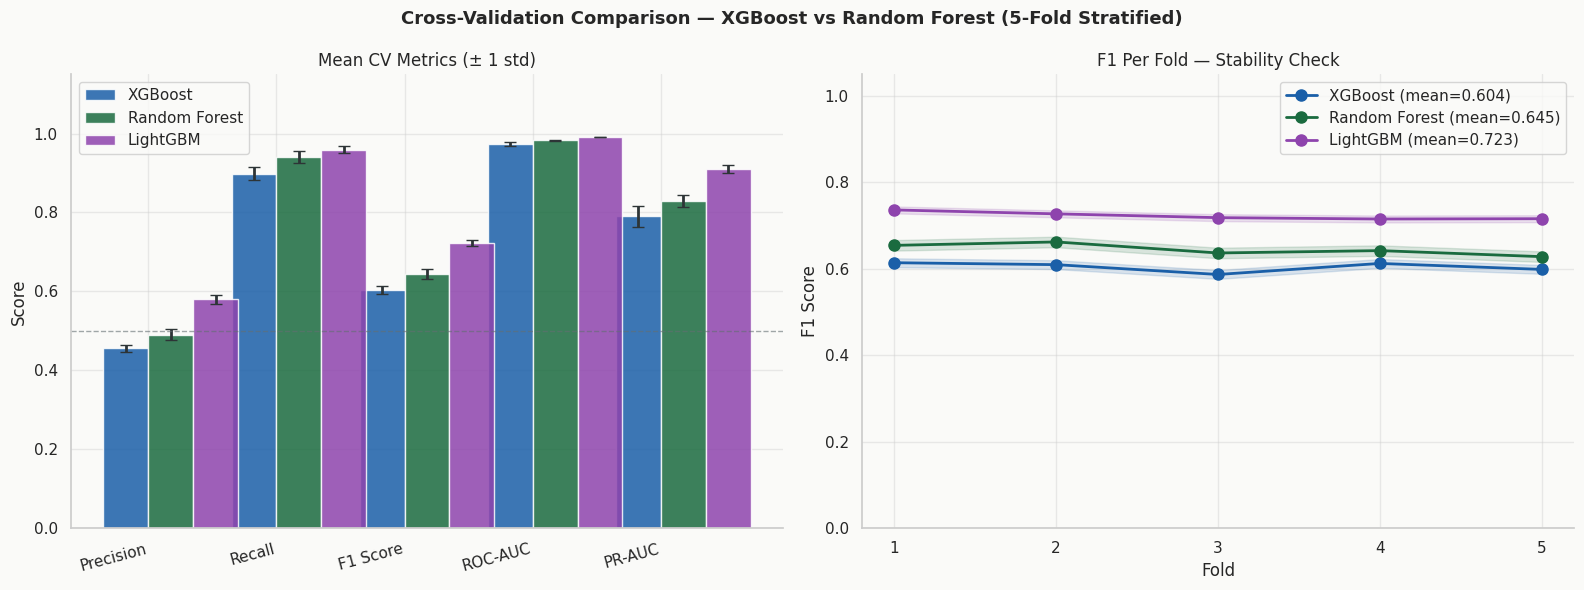

In [27]:
# CV comparison bar chart with error bars
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Cross-Validation Comparison — XGBoost vs Random Forest ({n_folds}-Fold Stratified)',
             fontsize=13, fontweight='bold')

metric_labels = {
    'precision'         : 'Precision',
    'recall'            : 'Recall',
    'f1'                : 'F1 Score',
    'roc_auc'           : 'ROC-AUC',
    'average_precision' : 'PR-AUC',
}
x   = np.arange(len(metric_labels))
w   = 0.35
clr = {'XGBoost':BLUE, 'Random Forest':GREEN,'LightGBM':PURPLE}

for ax_idx, (model_name, cv_res) in enumerate([('XGBoost',xgb_cv),('Random Forest',rf_cv),('LightGBM',lgbm_cv)]):
    means = [cv_res[f'test_{m}'].mean() for m in metric_labels.keys()]
    stds  = [cv_res[f'test_{m}'].std()  for m in metric_labels.keys()]

    offset = (ax_idx - 0.5) * w
    bars   = axes[0].bar(x + offset, means, w, yerr=stds, capsize=4,
                         label=model_name, color=clr[model_name], alpha=0.85,
                         error_kw={'elinewidth':2, 'ecolor':'#2d3436'})

axes[0].set_xticks(x)
axes[0].set_xticklabels(list(metric_labels.values()), rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Mean CV Metrics (± 1 std)')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].axhline(0.5, color=GREY, linestyle='--', linewidth=1, alpha=0.6, label='Baseline=0.5')

# Right: per-fold F1 progression
for model_name, cv_res, clr_val in [('XGBoost',xgb_cv,BLUE),('Random Forest',rf_cv,GREEN),('LightGBM',lgbm_cv,PURPLE)]:
    fold_f1 = cv_res['test_f1']
    axes[1].plot(range(1, n_folds+1), fold_f1, marker='o', linewidth=2,
                 markersize=8, color=clr_val, label=f'{model_name} (mean={fold_f1.mean():.3f})')
    axes[1].fill_between(range(1, n_folds+1),
                         fold_f1 - fold_f1.std(), fold_f1 + fold_f1.std(),
                         alpha=0.15, color=clr_val)

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Per Fold — Stability Check')
axes[1].set_xticks(range(1, n_folds+1))
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'reports/figures/_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Select a model for THIS NOTEBOOK'S diagnostics only 

with open('models/artifacts/supervised_results_registry.json') as f:
    registry = json.load(f)

# Sort by CV PR-AUC — informative for internal diagnostics; NOT the deployment metric
best_entry = sorted(registry, key=lambda x: x['cv_pr_auc_mean'], reverse=True)[0]
best_name  = best_entry['name']

# Map name → (trained clf object, test-set probability array)
model_map = {
    'XGBoost':       (xgb_clf,  xgb_prob),
    'Random Forest': (rf_clf,   rf_prob),
    'LightGBM':      (lgbm_clf, lgbm_prob),
}
best_clf, best_prob = model_map[best_name]

print('=' * 70)
print(f'  Model selected for NB05 diagnostics (SHAP / permutation / threshold plots)')
print(f'  Selected  : {best_name}')
print(f'  Criterion : CV PR-AUC vs pseudo-label (exploratory, NOT the deployment metric)')
print(f'  cv_pr_auc_mean : {best_entry["cv_pr_auc_mean"]:.4f} ± {best_entry["cv_pr_auc_std"]:.4f}')
print(f'  cv_roc_auc_mean: {best_entry["cv_roc_auc_mean"]:.4f}')
print('=' * 70)
print()
print('Full registry ranking (by CV PR-AUC vs pseudo-label):')
for rank, entry in enumerate(
        sorted(registry, key=lambda x: x['cv_pr_auc_mean'], reverse=True), 1):
    marker = '  ← used for diagnostics below' if entry['name'] == best_name else ''
    print(f'  {rank}. {entry["name"]:<16}  '
          f'cv_pr={entry["cv_pr_auc_mean"]:.4f}  '
          f'test_heuristic={entry["test_pr_auc_vs_heuristic"]:.4f}{marker}')
print()
print(f'Sections 9-11 (diagnostics only) will use: {best_name}')
print('Deployment model selection happens in NB06 Section 6 (PR-AUC vs heuristic label).')

  Model selected for NB05 diagnostics (SHAP / permutation / threshold plots)
  Selected  : LightGBM
  Criterion : CV PR-AUC vs pseudo-label (exploratory, NOT the deployment metric)
  cv_pr_auc_mean : 0.9094 ± 0.0105
  cv_roc_auc_mean: 0.9913

Full registry ranking (by CV PR-AUC vs pseudo-label):
  1. LightGBM          cv_pr=0.9094  test_heuristic=0.0671  ← used for diagnostics below
  2. Random Forest     cv_pr=0.8291  test_heuristic=0.0658
  3. XGBoost           cv_pr=0.7901  test_heuristic=0.0687

Sections 9-11 (diagnostics only) will use: LightGBM
Deployment model selection happens in NB06 Section 6 (PR-AUC vs heuristic label).


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>LightGBM has the best CV metrics of the three models:</b> CV PR-AUC 0.9094 ± 0.0105 and CV ROC-AUC 0.9913 ± 0.0010, ahead of Random Forest (0.8291 / 0.9829) and XGBoost (0.7901 / 0.9735). It also trains much faster than Random Forest (20.8s vs 168.9s), though slower than XGBoost (2.6s).</li>
<li><b>XGBoost has the smallest train/CV gap</b> (0.0096), followed by LightGBM (0.0204) and then Random Forest (0.0213), the largest of the three. All three stay comfortably under the notebook's 0.15 overfitting cutoff.</li>
<li><b>On the heuristic-label test set</b> (the more real-world-relevant comparison), Random Forest has the lowest PR-AUC (0.0658) and ROC-AUC (0.3166) of the three, XGBoost has the highest PR-AUC (0.0687), and LightGBM has the highest ROC-AUC (0.3369). All three are far below the pseudo-label numbers above, since the models were trained to match the pseudo-label, not the heuristic rule.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>9. Test-Set Evaluation — Side-by-Side</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Show confusion matrices, ROC curves, and PR curves for the final held-out test set, evaluated against both the pseudo-label (how well each model matches the ensemble) and the heuristic label (how well it matches the original NB03 rules).
</b></i></p>
<hr>

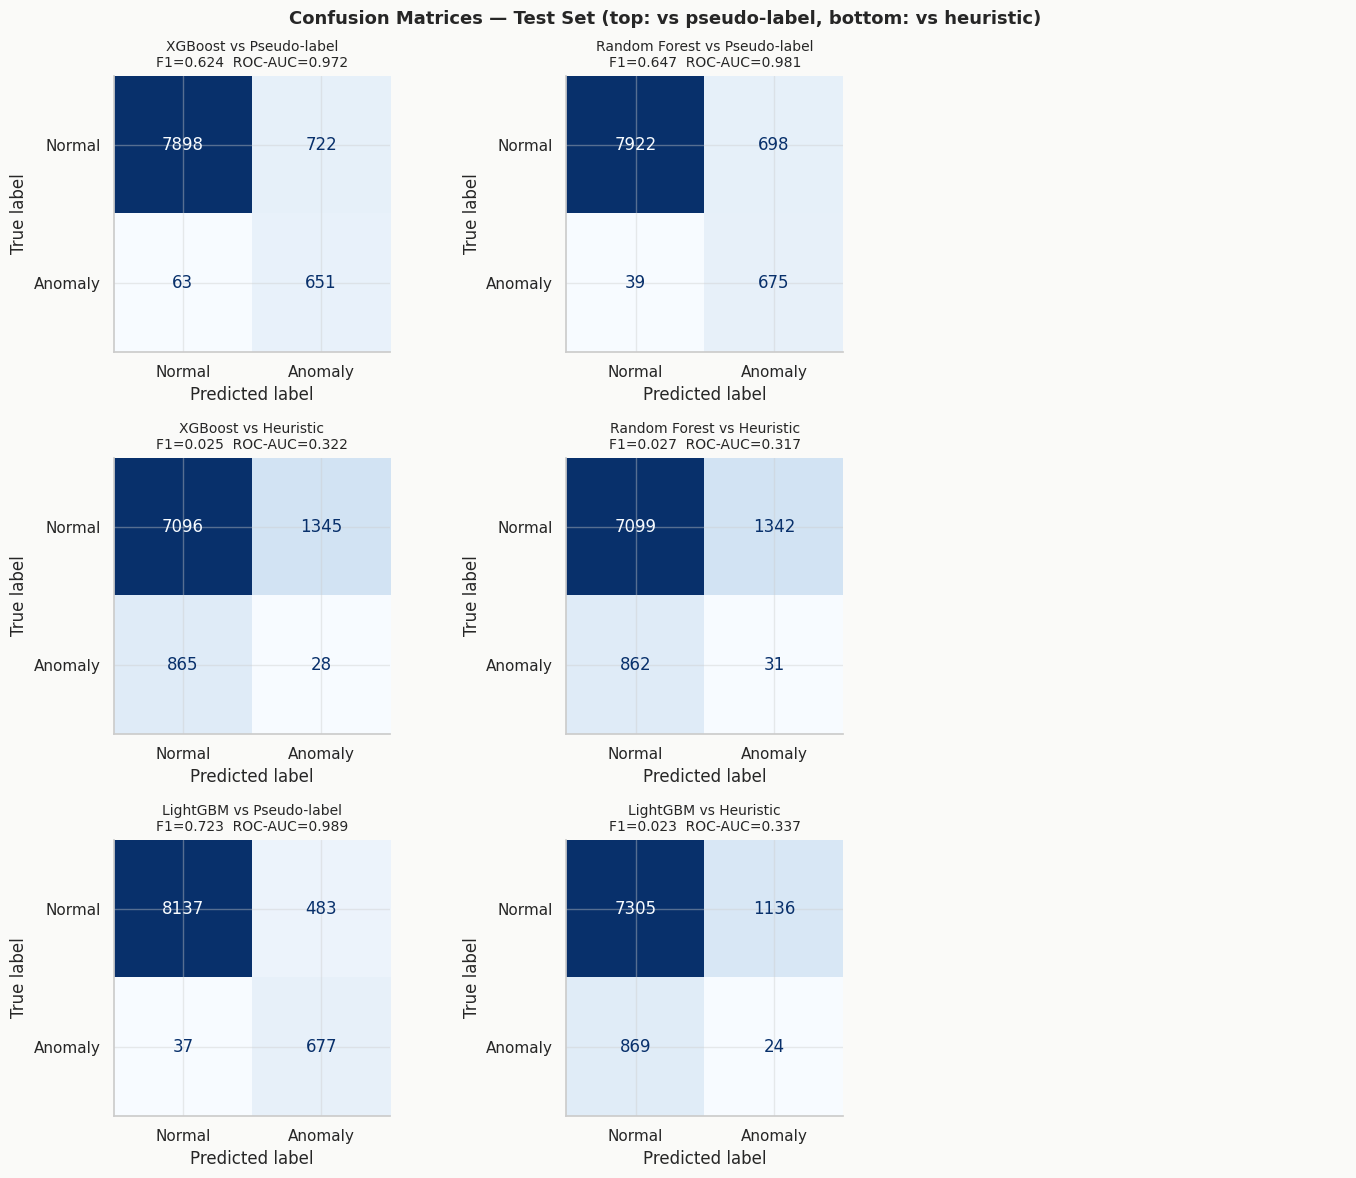

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle(
    'Confusion Matrices — Test Set (top: vs pseudo-label, bottom: vs heuristic)',
    fontsize=13,
    fontweight='bold'
)

combos = [
    (xgb_pred,  xgb_prob,  y_pseudo_test,  'XGBoost vs Pseudo-label',      axes[0][0]),
    (rf_pred,   rf_prob,   y_pseudo_test,  'Random Forest vs Pseudo-label', axes[0][1]),
    (xgb_pred,  xgb_prob,  y_test.values,  'XGBoost vs Heuristic',         axes[1][0]),
    (rf_pred,   rf_prob,   y_test.values,  'Random Forest vs Heuristic',   axes[1][1]),
    (lgbm_pred, lgbm_prob, y_pseudo_test,  'LightGBM vs Pseudo-label',     axes[2][0]),
    (lgbm_pred, lgbm_prob, y_test.values,  'LightGBM vs Heuristic',        axes[2][1]),
]

for pred, prob, ytrue, title, ax in combos:
    cm = confusion_matrix(ytrue, pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=['Normal', 'Anomaly']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    f1v = f1_score(ytrue, pred, zero_division=0)
    rocv = roc_auc_score(ytrue, prob)

    ax.set_title(
        f'{title}\nF1={f1v:.3f}  ROC-AUC={rocv:.3f}',
        fontsize=10
    )

# Hide unused subplot
axes[0][2].axis('off')
axes[1][2].axis('off')
axes[2][2].axis('off')

plt.tight_layout()
plt.savefig(
    'reports/figures/_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

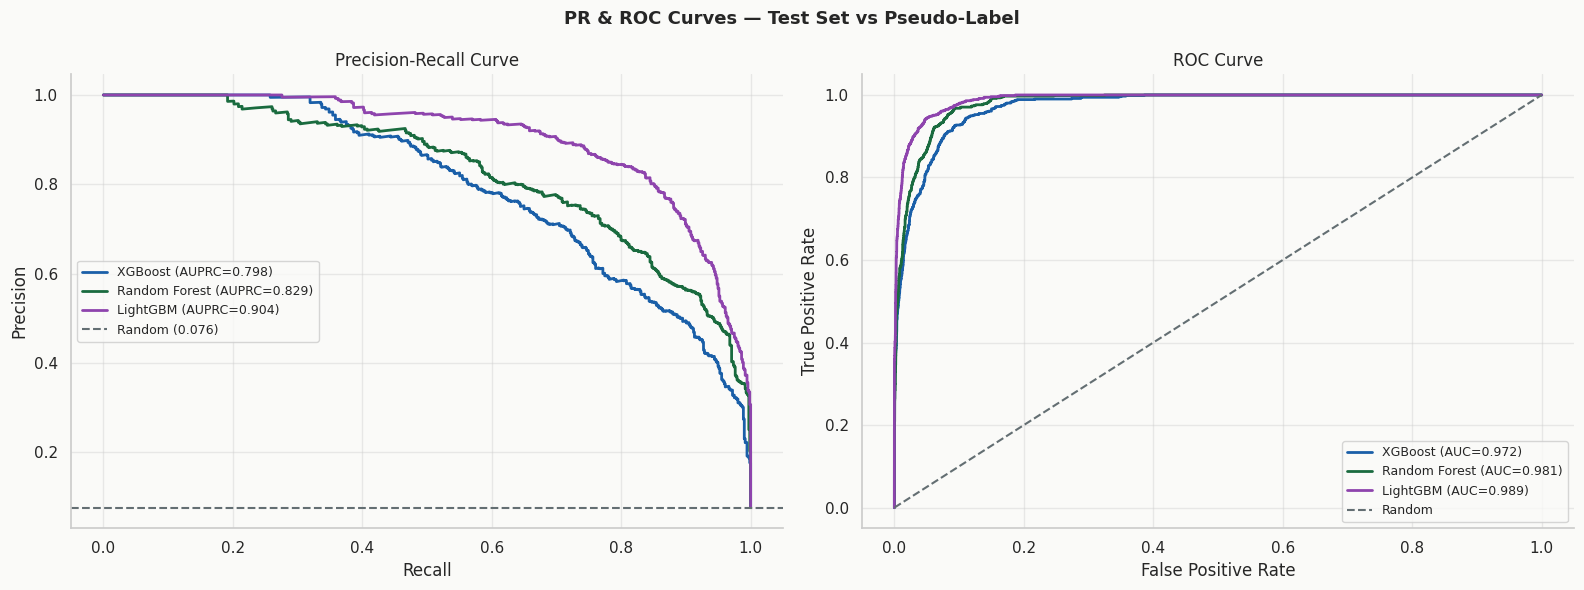

In [30]:
# PR and ROC curves — both models vs pseudo-label (primary evaluation)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PR & ROC Curves — Test Set vs Pseudo-Label',
             fontsize=13, fontweight='bold')

model_plot_info = [
    ('XGBoost',       xgb_prob, BLUE),
    ('Random Forest', rf_prob,  GREEN),
    ('LightGBM',     lgbm_prob, PURPLE),
]

for name, prob, clr in model_plot_info:
    prec_c, rec_c, _ = precision_recall_curve(y_pseudo_test, prob)
    fpr_c,  tpr_c, _ = roc_curve(y_pseudo_test, prob)
    ap_v  = average_precision_score(y_pseudo_test, prob)
    roc_v = roc_auc_score(y_pseudo_test, prob)
    axes[0].plot(rec_c, prec_c, color=clr, linewidth=2,
                 label=f'{name} (AUPRC={ap_v:.3f})')
    axes[1].plot(fpr_c, tpr_c,  color=clr, linewidth=2,
                 label=f'{name} (AUC={roc_v:.3f})')

baseline_rate = y_pseudo_test.mean()
axes[0].axhline(baseline_rate, color=GREY, linestyle='--', linewidth=1.5,
                label=f'Random ({baseline_rate:.3f})')
axes[1].plot([0,1],[0,1], color=GREY, linestyle='--', linewidth=1.5, label='Random')

axes[0].set_xlabel('Recall');            axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve');           axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'reports/figures/_pr_roc_supervised.png', dpi=150, bbox_inches='tight')
plt.show()

<h3 style="font-family:'Times New Roman'; color:red;"><b>10. Feature Importances — Random Forest (MDI) &amp; Best Model (Permutation)</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Show Random Forest's built-in feature importance (MDI), then use permutation importance on the winning model for a more reliable, model-agnostic view, since MDI can overstate the importance of high-cardinality features like price.
</b></i></p>
<hr>

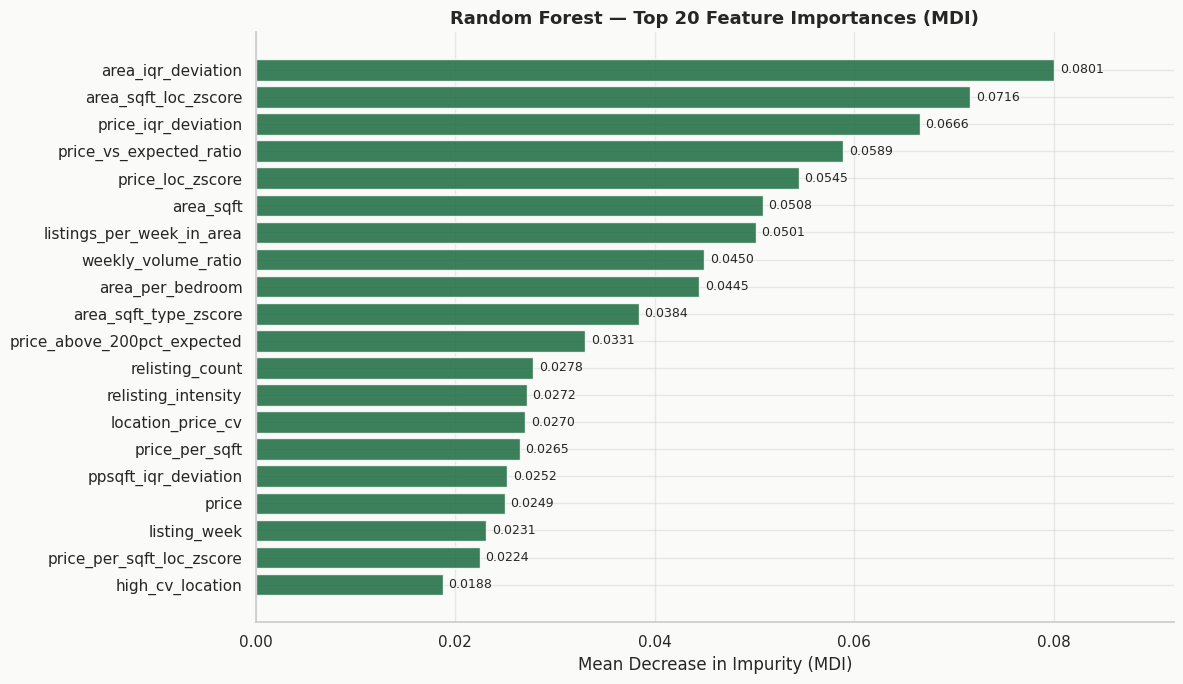

In [31]:
# Get feature importances from the retrained RF
importances_rf = pd.Series(rf_clf.feature_importances_, index=feature_cols)
importances_rf = importances_rf.sort_values(ascending=False)
top20_rf = importances_rf.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20_rf.index[::-1], top20_rf.values[::-1],
               color=GREEN, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Random Forest — Top 20 Feature Importances (MDI)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top20_rf.max() * 1.15)
plt.tight_layout()
plt.savefig(f'reports/figures/_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
print(f'Computing permutation importance on test set ({best_name})...')
t0 = time.time()

perm_result = permutation_importance(
    best_clf,
    X_test_robust,
    y_pseudo_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=seed,
    n_jobs=-1,
)
print(f'Done in {time.time()-t0:.1f}s')

perm_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': perm_result.importances_mean,
    'std':        perm_result.importances_std,
}).sort_values('importance', ascending=False).head(20)


Computing permutation importance on test set (LightGBM)...
Done in 23.8s


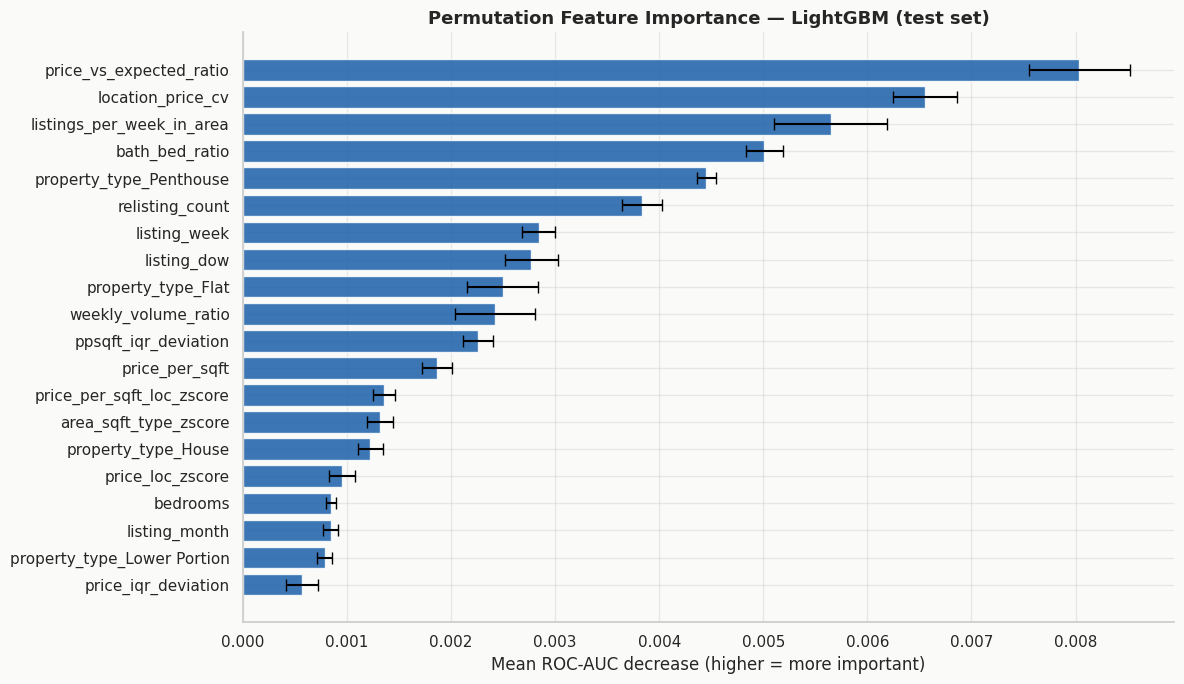


Top 10 features by permutation importance (LightGBM):
  price_vs_expected_ratio            : 0.00804 ± 0.00048
  location_price_cv                  : 0.00655 ± 0.00031
  listings_per_week_in_area          : 0.00565 ± 0.00054
  bath_bed_ratio                     : 0.00501 ± 0.00018
  property_type_Penthouse            : 0.00445 ± 0.00009
  relisting_count                    : 0.00384 ± 0.00019
  listing_week                       : 0.00284 ± 0.00016
  listing_dow                        : 0.00277 ± 0.00026
  property_type_Flat                 : 0.00250 ± 0.00034
  weekly_volume_ratio                : 0.00242 ± 0.00039


In [33]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    perm_df['feature'].iloc[::-1],
    perm_df['importance'].iloc[::-1],
    xerr=perm_df['std'].iloc[::-1],
    color=BLUE, alpha=0.85, capsize=4, edgecolor='white',
)
ax.set_xlabel('Mean ROC-AUC decrease (higher = more important)')
ax.set_title(f'Permutation Feature Importance — {best_name} (test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/permutation_importance_best.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 10 features by permutation importance ({best_name}):')
for _, row in perm_df.head(10).iterrows():
    print(f"  {row['feature']:<35}: {row['importance']:.5f} ± {row['std']:.5f}")


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Permutation importance effect sizes are modest:</b> the top feature, <code>price_vs_expected_ratio</code>, drops ROC-AUC by 0.00804 on average when shuffled. None of the top 10 features have a standard deviation larger than their importance value, so the ranking is reasonably stable.</li>
<li><b>Top features lean toward price context and structural ratios</b> rather than raw price or area: the top three are <code>price_vs_expected_ratio</code>, <code>location_price_cv</code>, and <code>listings_per_week_in_area</code>, suggesting the model relies more on how a listing compares to its local market than on simple value thresholds.</li>
<li><b>Computing permutation importance with 10 repeats on the test set took 23.8 seconds.</b></li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>11. SHAP Values — Best Model Explainability</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Use SHAP TreeExplainer on the winning model to explain individual predictions, not just global importance, with a bar plot, beeswarm plot, and dependence plot on a 2,000-row sample.
</b></i></p>
<hr>

In [ ]:
print(f'Computing SHAP values for {best_name}...')
t0 = time.time()

explainer   = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test_robust)  

# Random Forest returns a list [class0_shap, class1_shap]; extract class 1 (anomaly)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_time = time.time() - t0
print(f'SHAP values computed in {shap_time:.1f}s')
print(f'SHAP matrix shape: {shap_values.shape}  (rows=test samples, cols=features)')

# Expected value (base rate)
# For RF, expected_value is also a list — extract class 1
expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[1]
print(f'Expected value (base rate log-odds or probability): {expected_val:.4f}')


Computing SHAP values for LightGBM...
SHAP values computed in 5.6s
SHAP matrix shape: (9334, 43)  (rows=test samples, cols=features)
Expected value (base rate log-odds or probability): -2.2813


In [ ]:
# SHAP expected value sanity check
if best_name == 'Random Forest':
    expected_prob = float(expected_val)
else:
    expected_prob = 1 / (1 + np.exp(-float(expected_val)))

actual_rate = y_pseudo_train.mean()
print(f'Expected probability (from SHAP base): {expected_prob:.3f}')
print(f'Actual training anomaly rate          : {actual_rate:.3f}')
print(f'Difference                            : {abs(expected_prob - actual_rate):.3f}')
if abs(expected_prob - actual_rate) > 0.05:
    print('Note: SHAP base probability and training anomaly rate differ by >5%.')
    if best_name != 'Random Forest':
        print('      This is expected when scale_pos_weight is large — XGBoost/LightGBM'
              ' internal weighting shifts the base log-odds.')
    print('      Waterfall plots should be interpreted relative to the SHAP base value.')
else:
    print('SHAP base probability closely matches training anomaly rate.')


Expected probability (from SHAP base): 0.093
Actual training anomaly rate          : 0.066
Difference                            : 0.027
SHAP base probability closely matches training anomaly rate.


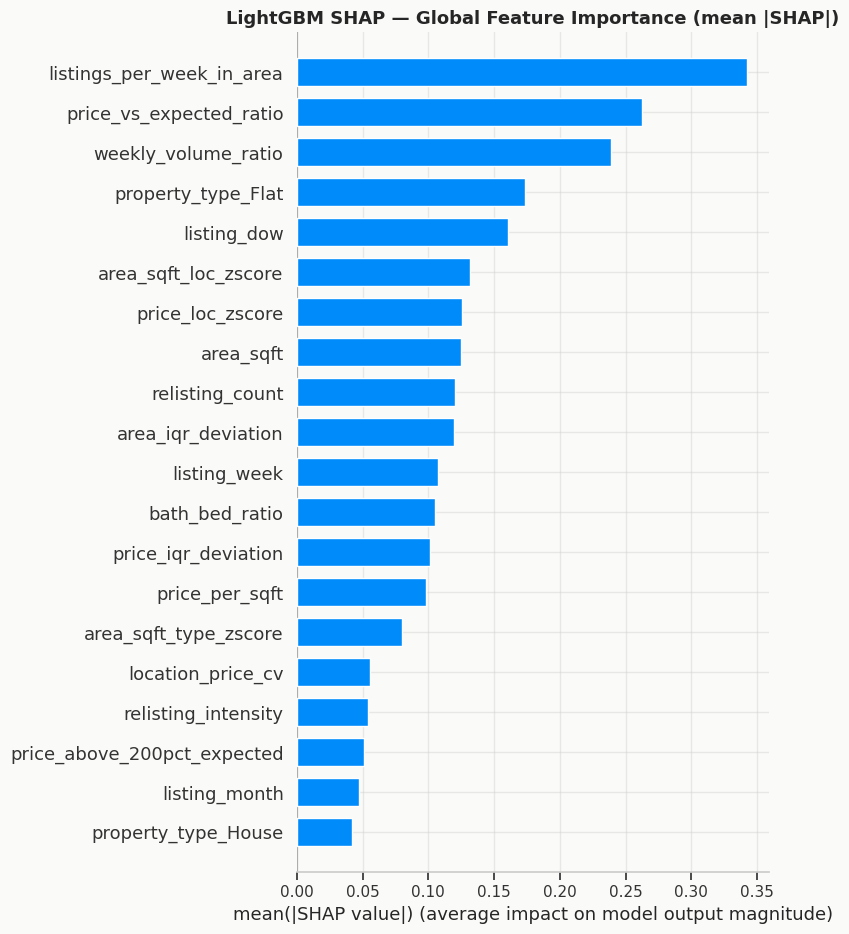

In [36]:
# SHAP Bar Plot — Global Feature Importance
shap.initjs()
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values, X_test_robust,
    feature_names = feature_cols,
    plot_type     = 'bar',
    max_display   = 20,
    show          = False,
)
plt.title(f'{best_name} SHAP — Global Feature Importance (mean |SHAP|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'reports/figures/_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


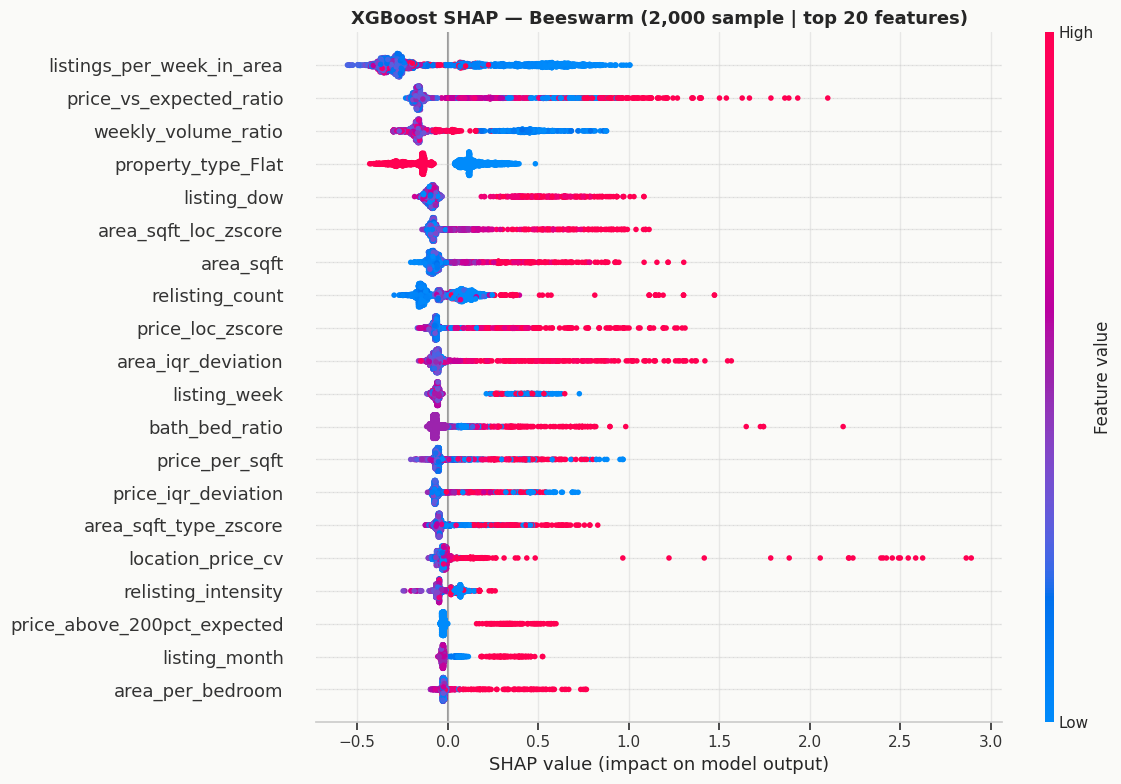

In [ ]:
# SHAP Beeswarm Plot — Importance + Direction

# Subsample for speed
rng        = np.random.RandomState(seed)
sample_idx = rng.choice(len(X_test_robust), size=min(2000, len(X_test_robust)), replace=False)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[sample_idx],
    X_test_robust[sample_idx],
    feature_names = feature_cols,
    max_display   = 20,
    show          = False,
    plot_size     = None,
)
plt.title('XGBoost SHAP — Beeswarm (2,000 sample | top 20 features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'reports/figures/_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

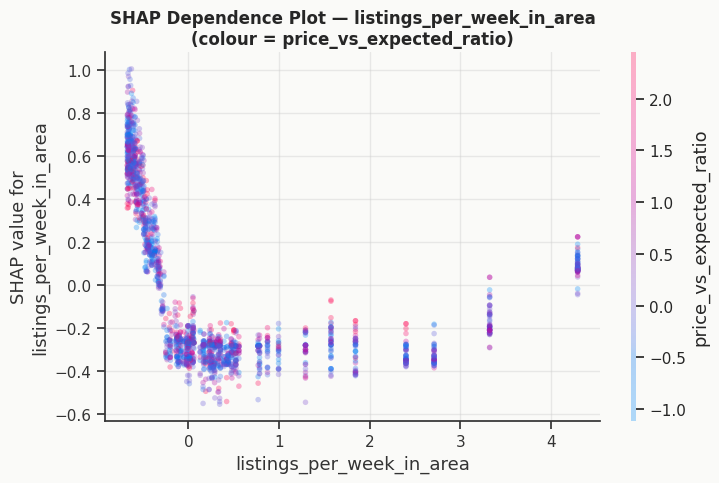

Top feature    : listings_per_week_in_area
Interaction col: price_vs_expected_ratio


In [ ]:
# SHAP Dependence Plot — Top Feature 
if len(shap_values.shape) == 3:
    shap_values_anomaly_class = shap_values[:, :, 1]
else:
    shap_values_anomaly_class = shap_values

mean_abs_shap = np.abs(shap_values_anomaly_class).mean(axis=0)
top_feature_idx = int(np.argmax(mean_abs_shap))
top_feature     = feature_cols[top_feature_idx]

# Choose interaction feature 
top2_idx      = int(np.argsort(mean_abs_shap)[::-1][1])
top2_feature  = feature_cols[top2_idx]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_values_anomaly_class[sample_idx],
    X_test_robust[sample_idx],
    feature_names       = feature_cols,
    interaction_index   = top2_idx,
    show                = False,
    alpha               = 0.3,
)
plt.title(
    f'SHAP Dependence Plot — {top_feature}\n'
    f'(colour = {top2_feature})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'reports/figures/_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top feature    : {top_feature}')
print(f'Interaction col: {top2_feature}')

Highest-risk listing — index 5855 | predicted anomaly prob: 0.9911


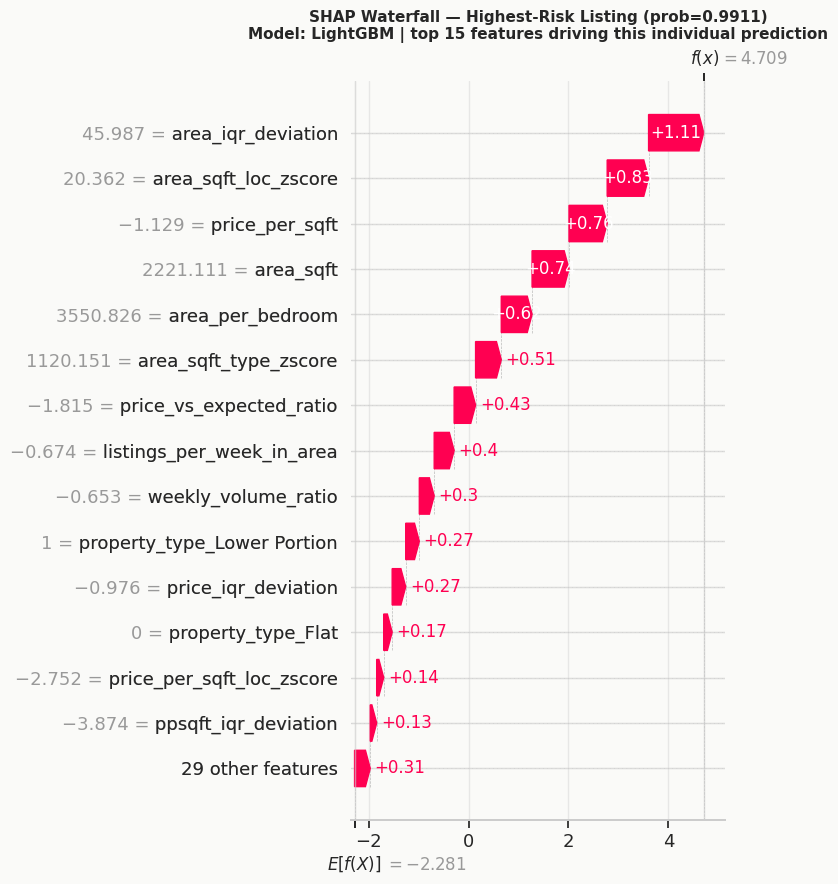

In [ ]:
# Waterfall Plot — Single Listing Explanation 
worst_idx  = int(np.argmax(best_prob))
print(f'Highest-risk listing — index {worst_idx} | '
      f'predicted anomaly prob: {best_prob[worst_idx]:.4f}')

shap_exp = shap.Explanation(
    values         = shap_values_anomaly_class[worst_idx],
    base_values    = float(expected_val),
    data           = X_test_robust[worst_idx],
    feature_names  = feature_cols,
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — Highest-Risk Listing (prob={best_prob[worst_idx]:.4f})\n'
    f'Model: {best_name} | top 15 features driving this individual prediction',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'reports/figures/_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>SHAP base value is close to the actual anomaly rate:</b> the expected probability from SHAP is 0.093, while the actual training anomaly rate is 6.6%, a difference of 0.027. The notebook's own check confirms this is a close match.</li>
<li><b>Computing SHAP values for all 9,334 test listings took 5.6 seconds</b> with TreeExplainer.</li>
<li><b>Strongest single interaction in the dependence plot</b> is between <code>listings_per_week_in_area</code> (the top feature) and <code>price_vs_expected_ratio</code>.</li>
<li><b>The single highest-risk test listing (index 5855)</b> has a predicted anomaly probability of 0.9911, far above the SHAP base value of 0.093, meaning the model is very confident about this one listing.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>11a. Learning Curves (Bias-Variance Diagnosis)</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Plot training vs. validation PR-AUC as training data increases, for the winning model, to check for overfitting (big train/val gap) or underfitting (flat validation curve).
</b></i></p>
<hr>

In [ ]:

# faithful to the real, already-tuned model.
models = {
    'XGBoost':              clone(xgb_clf),
    'Random Forest':        clone(rf_clf),
    'LightGBM':              clone(lgbm_clf),

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        C=1.0,
        solver='lbfgs',
        random_state=seed,
    ),
}


In [41]:
model = models[best_name]

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_robust,
    y_pseudo_train,
    train_sizes=np.linspace(0.10, 1.0, 8),
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    ),
    scoring='average_precision',   # Better than roc_auc for fraud
    n_jobs=-1
)

In [ ]:
train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

# Print diagnosis
gap = train_mean[-1] - val_mean[-1]

base_rate = y_pseudo_train.mean()

print(f'\nAt full training size ({best_name}):')
print(f'  Train PR-AUC : {train_mean[-1]:.4f}')
print(f'  CV PR-AUC    : {val_mean[-1]:.4f}')
print(f'  Gap          : {gap:.4f}')
print(f'  (Reference — positive base rate / random PR-AUC floor: {base_rate:.4f})')

if gap > 0.10:
    print(f'  -> OVERFITTING detected for {best_name}. Try: lower max_depth, raise '
          f'min_samples_leaf/min_child_weight, raise reg_alpha/reg_lambda, or reduce max_samples/subsample.')
elif val_mean[-1] < base_rate * 1.5:
    print('  -> UNDERFITTING / weak signal. CV PR-AUC is barely above the random '
          'floor — this usually means the labels carry little learnable signal '
          'for these features, not that the model is too simple. Adding capacity '
          'is unlikely to help; consider revisiting label quality or features instead.')
else:
    print('  -> Acceptable fit. Gap is within the 0.10 tolerance for this problem.')



At full training size (LightGBM):
  Train PR-AUC : 0.9421
  CV PR-AUC    : 0.9094
  Gap          : 0.0326
  (Reference — positive base rate / random PR-AUC floor: 0.0659)
  -> Acceptable fit. Gap is within the 0.10 tolerance for this problem.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Acceptable fit for LightGBM at full training size:</b> Train PR-AUC 0.9421 vs CV PR-AUC 0.9094, a gap of 0.0326, which is within the notebook's 0.10 tolerance for this problem.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>12. Score Distribution &amp; Threshold Analysis (exploratory)</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Show the winning model's predicted-probability distribution and how precision, recall, and F1 change across thresholds. This is exploratory only — the actual production threshold is chosen separately in NB06 Section 9.
</b></i></p>
<hr>

In [43]:
# Precision-Recall curve for the winning model
prec, rec, thr = precision_recall_curve(y_pseudo_test, best_prob)

# thr has length = len(prec) - 1
prec_adj = prec[:-1]
rec_adj  = rec[:-1]

f1 = (2 * prec_adj * rec_adj) / (prec_adj + rec_adj + 1e-9)


In [44]:
# Best threshold by F1
best_idx = np.argmax(f1)
best_thr = thr[best_idx]

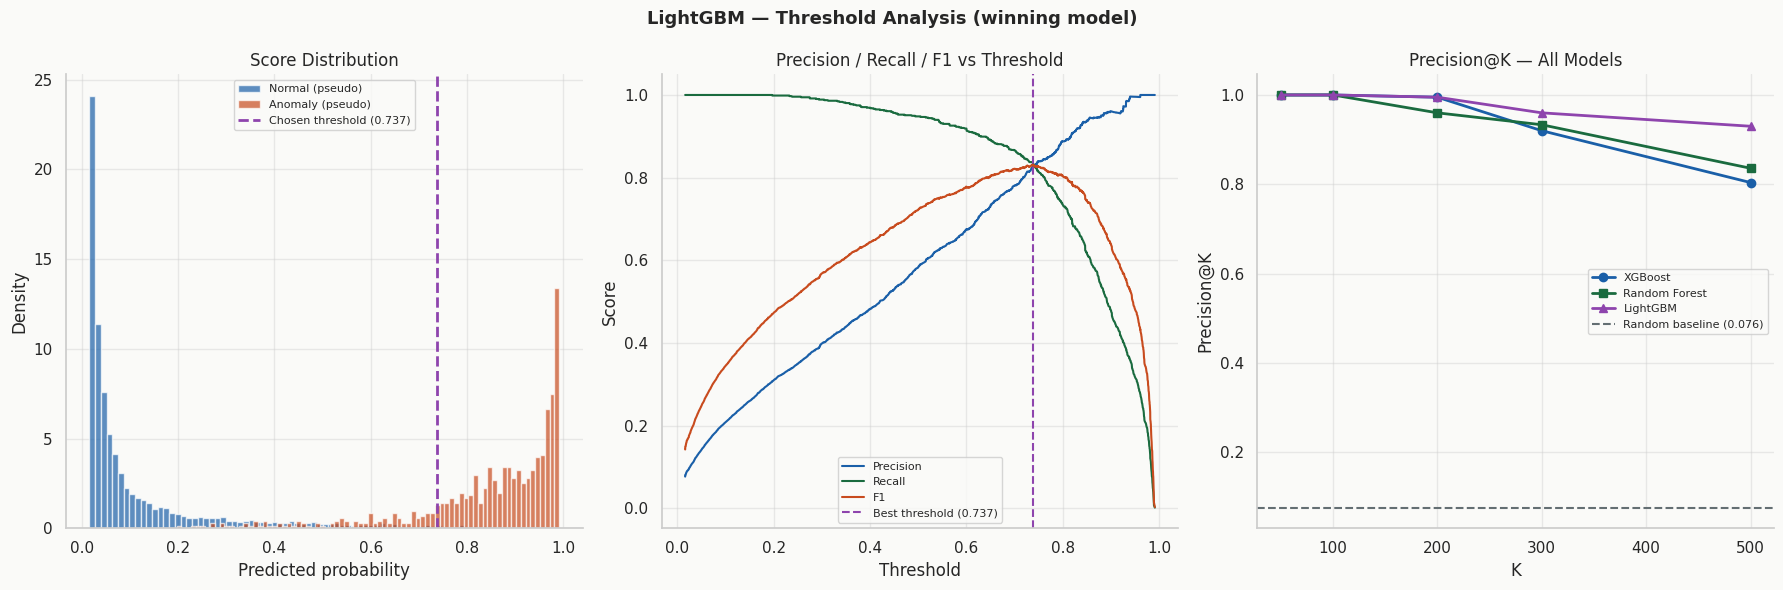

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'{best_name} — Threshold Analysis (winning model)',
             fontsize=13, fontweight='bold')

# --- Left: score distribution ---
axes[0].hist(best_prob[y_pseudo_test == 0], bins=80, color=BLUE, alpha=0.7,
             label='Normal (pseudo)', density=True)
axes[0].hist(best_prob[y_pseudo_test == 1], bins=80, color=ACCENT, alpha=0.7,
             label='Anomaly (pseudo)', density=True)
axes[0].axvline(best_thr, color=PURPLE, linestyle='--', linewidth=2,
                label=f'Chosen threshold ({best_thr:.3f})')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# --- Middle: PR + F1 vs threshold ---
axes[1].plot(thr, prec_adj, label='Precision', color=BLUE)
axes[1].plot(thr, rec_adj,  label='Recall',    color=GREEN)
axes[1].plot(thr, f1,       label='F1',        color=ACCENT)
axes[1].axvline(best_thr, color=PURPLE, linestyle='--',
                label=f'Best threshold ({best_thr:.3f})')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8)

# --- Right: Precision@K for all three models ---
def precision_at_k(y_true, scores, k):
    top_k = np.argsort(scores)[::-1][:k]
    return y_true[top_k].mean()

k_vals = [50, 100, 200, 300, 500]
p_at_k_xgb  = [precision_at_k(y_pseudo_test, xgb_prob,  k) for k in k_vals]
p_at_k_rf   = [precision_at_k(y_pseudo_test, rf_prob,   k) for k in k_vals]
p_at_k_lgbm = [precision_at_k(y_pseudo_test, lgbm_prob, k) for k in k_vals]

axes[2].plot(k_vals, p_at_k_xgb,  marker='o', linewidth=2, color=BLUE,   label='XGBoost')
axes[2].plot(k_vals, p_at_k_rf,   marker='s', linewidth=2, color=GREEN,  label='Random Forest')
axes[2].plot(k_vals, p_at_k_lgbm, marker='^', linewidth=2, color=PURPLE, label='LightGBM')

baseline = y_pseudo_test.mean()
axes[2].axhline(baseline, color=GREY, linestyle='--',
                label=f'Random baseline ({baseline:.3f})')
axes[2].set_title('Precision@K — All Models')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Precision@K')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('reports/figures/_threshold_analysis_best_model.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [46]:
# Final evaluation at the F1-optimal threshold (best model)
y_pred = (best_prob >= best_thr).astype(int)

p_best = precision_score(y_pseudo_test, y_pred, zero_division=0)
r_best = recall_score(y_pseudo_test, y_pred, zero_division=0)
f_best = f1_score(y_pseudo_test, y_pred, zero_division=0)

print(f'Winning model         : {best_name}')
print(f'Optimal threshold (F1): {best_thr:.4f}')
print(f'Precision             = {p_best:.4f}')
print(f'Recall                = {r_best:.4f}')
print(f'F1                    = {f_best:.4f}')


Winning model         : LightGBM
Optimal threshold (F1): 0.7374
Precision             = 0.8269
Recall                = 0.8361
F1                    = 0.8315


In [ ]:
xgb_prob_ordered  = np.full(len(scored_df), np.nan)
rf_prob_ordered   = np.full(len(scored_df), np.nan)
lgbm_prob_ordered = np.full(len(scored_df), np.nan)

xgb_prob_ordered[X_train_df.index]  = xgb_clf.predict_proba(X_train_robust)[:, 1]
xgb_prob_ordered[X_test_df.index]   = xgb_clf.predict_proba(X_test_robust)[:, 1]

rf_prob_ordered[X_train_df.index]   = rf_clf.predict_proba(X_train_robust)[:, 1]
rf_prob_ordered[X_test_df.index]    = rf_clf.predict_proba(X_test_robust)[:, 1]

lgbm_prob_ordered[X_train_df.index] = lgbm_clf.predict_proba(X_train_robust)[:, 1]
lgbm_prob_ordered[X_test_df.index]  = lgbm_clf.predict_proba(X_test_robust)[:, 1]

scored_df['xgb_prob']               = xgb_prob_ordered
scored_df['rf_prob']                = rf_prob_ordered
scored_df['lgbm_prob']              = lgbm_prob_ordered
scored_df['ensemble_anomaly_label'] = y_ensemble
scored_df['xgb_flag']               = (xgb_prob_ordered  >= best_thr if best_name == 'XGBoost'
                                        else xgb_prob_ordered  >= 0.5).astype(float)
scored_df['rf_flag']                = (rf_prob_ordered   >= best_thr if best_name == 'Random Forest'
                                        else rf_prob_ordered   >= 0.5).astype(float)
scored_df['lgbm_flag']              = (lgbm_prob_ordered >= best_thr if best_name == 'LightGBM'
                                        else lgbm_prob_ordered >= 0.5).astype(float)
scored_df['diagnostic_model_prob']  = np.where(
    ~np.isnan(xgb_prob_ordered),
    [xgb_prob_ordered, rf_prob_ordered, lgbm_prob_ordered]
    [['XGBoost', 'Random Forest', 'LightGBM'].index(best_name)],
    np.nan
)
scored_df['diagnostic_model_flag']  = (scored_df['diagnostic_model_prob'] >= best_thr).astype(float)

output_path = 'data/preprocessed/model_scored_listings.csv'
scored_df.to_csv(output_path, index=False)
print(f'Updated model_scored_listings.csv -> {output_path}')
print(f'  New columns: xgb_prob, rf_prob, lgbm_prob, ensemble_anomaly_label,')
print(f'               xgb_flag, rf_flag, lgbm_flag, diagnostic_model_prob, diagnostic_model_flag')
print(f'  Final shape : {scored_df.shape}')

print(f'\nDiagnostic threshold (this notebook only, model={best_name}): {best_thr:.4f}')
print('This value is NOT saved to disk and is NOT used by NB06 or the FastAPI service.')
print('The production threshold is selected independently in NB06 Section 9.')

Updated model_scored_listings.csv -> data/preprocessed/model_scored_listings.csv
  New columns: xgb_prob, rf_prob, lgbm_prob, ensemble_anomaly_label,
               xgb_flag, rf_flag, lgbm_flag, diagnostic_model_prob, diagnostic_model_flag
  Final shape : (46667, 93)

Diagnostic threshold (this notebook only, model=LightGBM): 0.7374
This value is NOT saved to disk and is NOT used by NB06 or the FastAPI service.
The production threshold is selected independently in NB06 Section 9.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>F1-optimal threshold for the diagnostic model (LightGBM) is 0.7374.</b> At this threshold, against the pseudo-label test set, Precision is 0.8269 and Recall is 0.8361, both fairly high and close to each other.</li>
<li><b>This is a balanced precision/recall point,</b> not a heavy trade-off in either direction, since the F1-optimal threshold here lands where precision and recall are close to equal.</li>
<li><b>This threshold is exploratory only and is not saved or reused:</b> it describes the diagnostic model on the pseudo-label test set. The production threshold is selected independently in Notebook 06 Section 9, on whichever model NB06's own (heuristic-label-based) selection and tuning process produces, which may differ from the model used here.</li>
</i></ul>
<hr>